# Longest Stay Detection - Full End-to-End Notebook

- **Coding Test:** Longest Stay Detection  
- **Dataset:** `entrance.mov`  
- **Objective:** หา `track_id` ของคนที่อยู่นิ่ง/หยุดเคลื่อนไหวนานที่สุด และรายงานระยะเวลาเป็นวินาที
- **Prepared by:** วิศิษฐ์ สุวรรณเนาว์ (Wisit Suwannao)

---

## Notebook Outline

1. Setup & Imports  
2. Data Structures  
3. Video Metadata Loading  
4. Geometry Helpers  
5. Stationary State Update  
6. Stationary Segment Computation  
7. Track Fragment Merging  
8. YOLO Detection + Multi-Object Tracking  
9. Video Annotation  
10. JSON/CSV Summary Export  
11. Full Pipeline Run  
12. Result Inspection & Visual Sanity Check

---

Notebook นี้เป็นเวอร์ชัน **full runnable walkthrough** มีโค้ด pipeline ครบทุกส่วนใน cell ตามลำดับ เพื่อให้ reviewer อ่านจากบนลงล่างแล้วเข้าใจทั้ง implementation และเหตุผลของแต่ละขั้นตอน

ไฟล์ `.py` ยังเป็น entrypoint หลักสำหรับรันจาก command line ส่วน notebook นี้ใช้เพื่ออธิบาย step และแสดง output แบบละเอียด

## Pipeline Architecture Overview

?????? pipeline ??????? input video, YOLO detection, multi-object tracking, stationary analytics ??????? output artifacts

![Longest Stay Detection pipeline](assets/longest_stay_pipeline.png)


# 0. Setup

ติดตั้ง dependencies ที่จำเป็นสำหรับงานนี้ ได้แก่:

- `opencv-python` สำหรับอ่าน metadata, อ่าน/เขียนวิดีโอ และวาด annotation
- `ultralytics` สำหรับ YOLO detector และ tracker API
- `lap` สำหรับ tracker association dependency ของ Ultralytics
- `numpy` สำหรับคำนวณค่าตัวเลข

ถ้า environment ยังไม่ได้ติดตั้ง package ให้ uncomment แล้วรัน cell ด้านล่าง จากนั้น restart kernel หาก notebook แจ้งเตือนเรื่อง package ใหม่


In [1]:
# !pip install -r requirements.txt

# 1. Imports and Type Aliases

ส่วนนี้รวม dependency ทั้งหมดที่ pipeline ต้องใช้ และกำหนด type alias สำหรับ bbox/point เพื่อให้ function signature อ่านง่ายขึ้น

มี error handling ตั้งแต่ต้น ถ้าขาด `opencv-python` หรือ `numpy` จะบอกวิธีติดตั้งทันที แทนที่จะไป error ลึก ๆ ตอนรันกลาง pipeline


In [ ]:
from __future__ import annotations

import argparse
import csv
import json
import math
import sys
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
from statistics import median
from typing import Any

try:
    import cv2
except ImportError as exc:  # pragma: no cover - exercised only on incomplete environments.
    raise SystemExit(
        "Missing dependency 'opencv-python'. Install dependencies with "
        "`python -m pip install -r requirements.txt`."
    ) from exc

try:
    import numpy as np
except ImportError as exc:  # pragma: no cover - exercised only on incomplete environments.
    raise SystemExit(
        "Missing dependency 'numpy'. Install dependencies with "
        "`python -m pip install -r requirements.txt`."
    ) from exc


BBox = tuple[float, float, float, float]
Point = tuple[float, float]

# 2. Data Structures

ใช้ `dataclass` เพื่อทำให้ข้อมูลแต่ละชนิดมีหน้าที่ชัดเจน ลดความสับสนจากการส่ง dictionary ซ้อนกันหลายชั้น

- `VideoMetadata`: เก็บ width, height, FPS, frame count และ duration จาก OpenCV
- `TrackObservation`: เก็บข้อมูลของ track หนึ่งคนใน frame หนึ่ง เช่น bbox, foot point, confidence, displacement
- `StationarySegment`: เก็บช่วงเวลาที่ track อยู่นิ่ง พร้อมคำนวณ duration
- `TrackState`: เก็บ state ระหว่างประมวลผล เช่น recent observations, stationary state, hysteresis state
- `FrameAnnotation`: เก็บข้อมูลสำหรับวาดกรอบและ label ลงวิดีโอ
- `TrackSummary`: เก็บ summary สุดท้ายของแต่ละ track ก่อน export เป็น JSON/CSV

การแยกข้อมูลแบบนี้ช่วยให้ reviewer เห็นชัดว่า pipeline ทำงานกับข้อมูลประเภทไหนในแต่ละช่วง


In [ ]:
@dataclass(frozen=True)
class VideoMetadata:
    width: int
    height: int
    fps: float
    frame_count: int
    duration_sec: float


@dataclass
class TrackObservation:
    frame_idx: int
    timestamp: float
    bbox: BBox
    foot: Point
    smoothed_foot: Point
    bbox_height: float
    confidence: float
    norm_disp: float | None = None
    window_iou: float | None = None
    stationary_candidate: bool = False


@dataclass
class StationarySegment:
    start_time: float
    end_time: float

    @property
    def duration(self) -> float:
        return max(0.0, self.end_time - self.start_time)

    def to_dict(self) -> dict[str, float]:
        return {
            "start_time": round(self.start_time, 3),
            "end_time": round(self.end_time, 3),
            "duration": round(self.duration, 3),
        }


@dataclass
class TrackState:
    track_id: int
    observations: list[TrackObservation] = field(default_factory=list)
    recent: deque[TrackObservation] = field(default_factory=deque)
    is_stationary: bool = False
    stationary_candidate_since: float | None = None
    stationary_started_at: float | None = None
    moving_since: float | None = None
    last_seen_frame: int = -1
    last_seen_time: float = 0.0
    last_smoothed_foot: Point | None = None

    @property
    def first_seen_time(self) -> float:
        return self.observations[0].timestamp if self.observations else 0.0

    @property
    def visible_time(self) -> float:
        if not self.observations:
            return 0.0
        return self.observations[-1].timestamp - self.observations[0].timestamp


@dataclass
class FrameAnnotation:
    track_id: int
    bbox: BBox
    confidence: float
    status: str
    stationary_duration: float
    norm_disp: float | None


@dataclass
class TrackSummary:
    track_id: int
    source_track_ids: list[int]
    total_visible_time: float
    first_seen_time: float
    last_seen_time: float
    stationary_segments: list[StationarySegment]

    @property
    def longest_segment(self) -> StationarySegment | None:
        if not self.stationary_segments:
            return None
        return max(self.stationary_segments, key=lambda segment: segment.duration)

# 3. Video Metadata Loading

โจทย์ระบุว่าห้าม hard-code FPS หรือความยาววิดีโอ ดังนั้นขั้นแรกต้องอ่าน metadata จากไฟล์จริงด้วย OpenCV

Function `load_video_metadata` ทำหน้าที่:

1. ตรวจว่าไฟล์วิดีโอมีอยู่จริง
2. เปิดวิดีโอด้วย `cv2.VideoCapture`
3. อ่าน width, height, FPS และ frame count
4. คำนวณ duration จาก `frame_count / fps`
5. validate metadata เพื่อกันกรณี OpenCV เปิดวิดีโอไม่ได้หรืออ่านค่าไม่ได้

Output ของ cell ถัดไปควรแสดง metadata ของ `entrance.mov` เช่น resolution, FPS และจำนวน frame


In [ ]:
def load_video_metadata(video_path: str | Path) -> VideoMetadata:
    path = Path(video_path)
    if not path.exists():
        raise FileNotFoundError(f"Video not found: {path}")

    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"OpenCV could not open video: {path}")

    try:
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = float(cap.get(cv2.CAP_PROP_FPS))
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    finally:
        cap.release()

    if width <= 0 or height <= 0:
        raise RuntimeError("Video metadata is invalid: width/height are unavailable.")
    if fps <= 0:
        raise RuntimeError("Video metadata is invalid: FPS is unavailable.")
    if frame_count <= 0:
        raise RuntimeError("Video metadata is invalid: frame count is unavailable.")

    return VideoMetadata(
        width=width,
        height=height,
        fps=fps,
        frame_count=frame_count,
        duration_sec=frame_count / fps,
    )

In [5]:
metadata = load_video_metadata('entrance.mov')
metadata

VideoMetadata(width=1920, height=1080, fps=29.882504238031217, frame_count=2556, duration_sec=85.535)

# 4. Geometry Helper Functions

ส่วนนี้เป็น helper สำหรับคำนวณตำแหน่งและความใกล้เคียงของ bbox

- `bbox_iou`: วัดว่า bbox สองอันซ้อนทับกันมากแค่ไหน ใช้เป็น evidence เสริมว่าคนยังอยู่ตำแหน่งเดิม
- `foot_point`: ใช้ `(center_x, y2)` แทนตำแหน่งคนบนพื้น
- `euclidean`: คำนวณระยะทางระหว่างจุดสองจุด

เหตุผลที่ใช้ foot point แทน bbox center: bbox center อาจแกว่งจากท่าทาง แขน ศีรษะ หรือการก้มเงย แต่ foot point สะท้อนตำแหน่งบนพื้นได้ดีกว่าในโจทย์ที่สนใจว่า “คนยืนอยู่ที่เดิมไหม”


In [ ]:
def bbox_iou(a: BBox, b: BBox) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area
    if union <= 0:
        return 0.0
    return inter_area / union


def foot_point(bbox: BBox) -> Point:
    x1, _, x2, y2 = bbox
    return ((x1 + x2) / 2.0, y2)


def euclidean(a: Point, b: Point) -> float:
    return math.hypot(a[0] - b[0], a[1] - b[1])

# 5. Stationary State Update

`update_track_state` คือแกนหลักของงานนี้ เพราะเป็นจุดที่แปลง observation ของแต่ละ frame ให้กลายเป็นสถานะ `moving` หรือ `stationary`

สิ่งที่ทำในแต่ละ frame:

1. คำนวณ foot point จาก bbox
2. Smooth foot point ด้วย EMA เพื่อลด jitter จาก detector
3. เก็บ observation ลง history ของ track นั้น
4. ตัด history ให้เหลือเฉพาะ sliding window เช่น 1 วินาทีล่าสุด
5. คำนวณ displacement ระหว่างตำแหน่งปัจจุบันกับตำแหน่งเก่าใน window
6. Normalize displacement ด้วย median bbox height เพื่อให้ threshold ใช้ได้กับคนใกล้/ไกลกล้อง
7. ใช้ bbox IoU เป็น evidence เสริม ถ้า bbox ยังซ้อนทับสูงแปลว่าน่าจะยังอยู่ตำแหน่งเดิม
8. ใช้ hysteresis เพื่อกันการสลับสถานะถี่จาก detection jitter

สูตรสำคัญ:

```text
norm_disp = distance(current_smoothed_foot, old_smoothed_foot) / median_bbox_height
```

ถ้า `norm_disp` ต่ำกว่า `stationary_threshold` ต่อเนื่องนานพอ จึงเริ่มนับ stationary segment


In [ ]:
def update_track_state(
    state: TrackState,
    frame_idx: int,
    timestamp: float,
    bbox: BBox,
    confidence: float,
    window_sec: float,
    stationary_threshold: float,
    min_stationary_sec: float,
    iou_threshold: float,
    exit_hysteresis_sec: float,
    ema_alpha: float = 0.35,
) -> FrameAnnotation:
    foot = foot_point(bbox)
    bbox_height = max(1.0, bbox[3] - bbox[1])

    if state.last_smoothed_foot is None:
        smoothed_foot = foot
    else:
        smoothed_foot = (
            ema_alpha * foot[0] + (1.0 - ema_alpha) * state.last_smoothed_foot[0],
            ema_alpha * foot[1] + (1.0 - ema_alpha) * state.last_smoothed_foot[1],
        )

    observation = TrackObservation(
        frame_idx=frame_idx,
        timestamp=timestamp,
        bbox=bbox,
        foot=foot,
        smoothed_foot=smoothed_foot,
        bbox_height=bbox_height,
        confidence=confidence,
    )

    state.recent.append(observation)
    while state.recent and state.recent[0].timestamp < timestamp - window_sec:
        state.recent.popleft()

    candidate = False
    norm_disp: float | None = None
    window_iou: float | None = None
    if len(state.recent) >= 2:
        reference = state.recent[0]
        window_age = timestamp - reference.timestamp
        if window_age >= max(0.20, window_sec * 0.65):
            median_height = max(1.0, median(obs.bbox_height for obs in state.recent))
            norm_disp = euclidean(smoothed_foot, reference.smoothed_foot) / median_height
            window_iou = bbox_iou(bbox, reference.bbox)
            candidate = norm_disp <= stationary_threshold or (
                norm_disp <= stationary_threshold * 1.5 and window_iou >= iou_threshold
            )

    observation.norm_disp = norm_disp
    observation.window_iou = window_iou
    observation.stationary_candidate = candidate
    state.observations.append(observation)

    if candidate:
        state.moving_since = None
        if state.stationary_candidate_since is None:
            state.stationary_candidate_since = timestamp
        if (
            not state.is_stationary
            and timestamp - state.stationary_candidate_since >= min_stationary_sec
        ):
            state.is_stationary = True
            state.stationary_started_at = state.stationary_candidate_since
    else:
        state.stationary_candidate_since = None
        if state.is_stationary:
            if state.moving_since is None:
                state.moving_since = timestamp
            if timestamp - state.moving_since >= exit_hysteresis_sec:
                state.is_stationary = False
                state.stationary_started_at = None
                state.moving_since = None
        else:
            state.moving_since = None

    state.last_seen_frame = frame_idx
    state.last_seen_time = timestamp
    state.last_smoothed_foot = smoothed_foot

    stationary_duration = (
        timestamp - state.stationary_started_at
        if state.is_stationary and state.stationary_started_at is not None
        else 0.0
    )
    return FrameAnnotation(
        track_id=state.track_id,
        bbox=bbox,
        confidence=confidence,
        status="stationary" if state.is_stationary else "moving",
        stationary_duration=stationary_duration,
        norm_disp=norm_disp,
    )

# 6. Stationary Segment Computation

หลังจากแต่ละ frame มี `stationary_candidate` แล้ว ยังต้องรวม frame เหล่านั้นให้เป็น segment ที่มี `start_time`, `end_time`, และ `duration`

`compute_stationary_segments` ช่วยแก้ปัญหาเหล่านี้:

- ไม่เริ่ม segment จาก frame เดียวที่นิ่งชั่วคราว
- ไม่ปิด segment ทันทีเมื่อมี jitter สั้น ๆ
- ปิด segment เมื่อมี moving evidence ต่อเนื่องนานพอ
- ปิด segment ถ้า detection หายไปนานเกิน threshold
- กรอง segment ที่สั้นเกิน `min_stationary_sec`

ผลลัพธ์ของ function นี้คือ list ของ stationary segments ต่อ track


In [ ]:
def compute_stationary_segments(
    observations: list[TrackObservation],
    min_stationary_sec: float,
    exit_hysteresis_sec: float,
    max_missing_sec: float,
) -> list[StationarySegment]:
    if not observations:
        return []

    sorted_observations = sorted(observations, key=lambda obs: (obs.timestamp, obs.frame_idx))
    segments: list[StationarySegment] = []
    candidate_since: float | None = None
    active_start: float | None = None
    moving_since: float | None = None
    previous_time = sorted_observations[0].timestamp

    for obs in sorted_observations:
        if active_start is not None and obs.timestamp - previous_time > max_missing_sec:
            segments.append(StationarySegment(active_start, previous_time))
            active_start = None
            candidate_since = None
            moving_since = None

        if obs.stationary_candidate:
            moving_since = None
            if candidate_since is None:
                candidate_since = obs.timestamp
            if active_start is None and obs.timestamp - candidate_since >= min_stationary_sec:
                active_start = candidate_since
        else:
            candidate_since = None
            if active_start is not None:
                if moving_since is None:
                    moving_since = obs.timestamp
                if obs.timestamp - moving_since >= exit_hysteresis_sec:
                    segments.append(StationarySegment(active_start, moving_since))
                    active_start = None
                    moving_since = None

        previous_time = obs.timestamp

    if active_start is not None:
        segments.append(StationarySegment(active_start, sorted_observations[-1].timestamp))

    return [segment for segment in segments if segment.duration >= min_stationary_sec]

# 7. Conservative Track Fragment Merging

Multi-object tracker อาจเกิด track fragmentation เมื่อคนถูกบัง detection หลุด หรือ confidence ต่ำ ทำให้คนเดิมอาจได้ track id ใหม่

`merge_track_fragments` เป็น heuristic แบบระมัดระวัง ไม่ merge ถ้า evidence ไม่ชัด โดยดูจาก:

- gap เวลาระหว่าง track เก่าและ track ใหม่ต้องสั้น
- foot point ตอนจบ/เริ่มต้องอยู่ใกล้กันหลัง normalize ด้วย bbox height
- bbox height ต้องมีขนาดใกล้เคียงกัน

จุดนี้ช่วยลดปัญหา ID fragmentation ใน summary แต่ยังไม่ aggressive เกินไปจนเอาคนละคนมา merge กันง่าย ๆ


In [ ]:
def merge_track_fragments(
    tracks: dict[int, TrackState],
    max_gap_sec: float = 0.70,
    max_norm_distance: float = 0.35,
    min_height_ratio: float = 0.60,
) -> dict[int, list[int]]:
    """Conservatively merge short track fragments that look spatially continuous."""
    ordered = sorted(
        (track for track in tracks.values() if track.observations),
        key=lambda track: track.first_seen_time,
    )
    parent: dict[int, int] = {track.track_id: track.track_id for track in ordered}

    def root(track_id: int) -> int:
        while parent[track_id] != track_id:
            parent[track_id] = parent[parent[track_id]]
            track_id = parent[track_id]
        return track_id

    for current in ordered:
        current_root = root(current.track_id)
        current_last = tracks[current_root].observations[-1]
        for candidate in ordered:
            if candidate.track_id == current_root or root(candidate.track_id) != candidate.track_id:
                continue
            gap = candidate.first_seen_time - current_last.timestamp
            if gap < 0 or gap > max_gap_sec:
                continue

            candidate_first = candidate.observations[0]
            size_ratio = min(current_last.bbox_height, candidate_first.bbox_height) / max(
                current_last.bbox_height,
                candidate_first.bbox_height,
            )
            median_height = max(1.0, (current_last.bbox_height + candidate_first.bbox_height) / 2.0)
            norm_distance = euclidean(
                current_last.smoothed_foot,
                candidate_first.smoothed_foot,
            ) / median_height

            if size_ratio >= min_height_ratio and norm_distance <= max_norm_distance:
                parent[candidate.track_id] = current_root

    groups: dict[int, list[int]] = defaultdict(list)
    for track_id in parent:
        groups[root(track_id)].append(track_id)
    return {root_id: sorted(ids) for root_id, ids in groups.items()}


def build_track_summaries(
    tracks: dict[int, TrackState],
    groups: dict[int, list[int]],
    min_stationary_sec: float,
    exit_hysteresis_sec: float,
    max_missing_sec: float,
) -> list[TrackSummary]:
    summaries: list[TrackSummary] = []
    for root_id, source_ids in groups.items():
        observations: list[TrackObservation] = []
        for source_id in source_ids:
            observations.extend(tracks[source_id].observations)
        observations.sort(key=lambda obs: (obs.timestamp, obs.frame_idx))
        if not observations:
            continue

        segments = compute_stationary_segments(
            observations,
            min_stationary_sec=min_stationary_sec,
            exit_hysteresis_sec=exit_hysteresis_sec,
            max_missing_sec=max_missing_sec,
        )
        summaries.append(
            TrackSummary(
                track_id=root_id,
                source_track_ids=source_ids,
                total_visible_time=observations[-1].timestamp - observations[0].timestamp,
                first_seen_time=observations[0].timestamp,
                last_seen_time=observations[-1].timestamp,
                stationary_segments=segments,
            )
        )
    return sorted(summaries, key=lambda summary: summary.track_id)

# 8. YOLO Model Loading and Detection Extraction

ส่วนนี้โหลด pretrained YOLO model และแปลงผลลัพธ์จาก Ultralytics ให้เป็น format ที่ pipeline ใช้ต่อได้

`load_yolo_model` มี fallback model เพื่อให้รันได้แม้ model ที่เลือกโหลดไม่ได้:

1. model ที่ user ระบุ เช่น `yolo11s.pt`
2. fallback `yolo11n.pt`
3. fallback `yolov8n.pt`

`extract_track_detections` ดึงข้อมูลสำคัญจากผลลัพธ์ของ tracker:

- `track_id`
- bbox แบบ `xyxy`
- confidence score


In [ ]:
def load_yolo_model(model_name: str) -> Any:
    try:
        from ultralytics import YOLO
    except ImportError as exc:
        raise RuntimeError(
            "Missing dependency 'ultralytics'. Install dependencies with "
            "`python -m pip install -r requirements.txt`."
        ) from exc

    candidates = [model_name]
    for fallback in ("yolo11n.pt", "yolov8n.pt"):
        if fallback not in candidates:
            candidates.append(fallback)

    errors: list[str] = []
    for candidate in candidates:
        try:
            print(f"Loading YOLO model: {candidate}", flush=True)
            return YOLO(candidate)
        except Exception as exc:  # noqa: BLE001 - keep fallback helpful for model download failures.
            errors.append(f"{candidate}: {exc}")

    raise RuntimeError("Could not load any YOLO model:\n" + "\n".join(errors))


def extract_track_detections(result: Any) -> list[tuple[int, BBox, float]]:
    boxes = getattr(result, "boxes", None)
    if boxes is None or boxes.id is None:
        return []

    xyxy = boxes.xyxy.cpu().numpy()
    ids = boxes.id.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy() if boxes.conf is not None else np.ones(len(ids), dtype=float)

    detections: list[tuple[int, BBox, float]] = []
    for track_id, bbox_arr, conf in zip(ids, xyxy, confs, strict=False):
        x1, y1, x2, y2 = [float(value) for value in bbox_arr]
        detections.append((int(track_id), (x1, y1, x2, y2), float(conf)))
    return detections

# 9. Detection + Multi-Object Tracking Loop

`run_detection_tracking` คือ loop หลักที่อ่านวิดีโอทีละ frame แล้วเรียก YOLO tracking

ค่าที่สำคัญใน `model.track(...)`:

- `classes=[0]`: detect เฉพาะ class person
- `persist=True`: ให้ tracker รักษา identity ต่อเนื่องข้าม frame
- `tracker=args.tracker`: ใช้ `botsort.yaml` หรือ `bytetrack.yaml`
- `conf=args.conf`: ปรับ threshold detection ได้จาก CLI/config
- `imgsz=args.imgsz`: ปรับ resolution ตอน inference ได้ ถ้าคนเล็กหรือไกลกล้อง

ผลจาก loop นี้คือ:

- `tracks`: state และ observations ของทุก track
- `frame_annotations`: ข้อมูลที่ใช้วาด annotated video ใน pass ถัดไป


In [ ]:
def run_detection_tracking(args: argparse.Namespace, metadata: VideoMetadata) -> tuple[
    dict[int, TrackState],
    dict[int, list[FrameAnnotation]],
]:
    model = load_yolo_model(args.model)
    cap = cv2.VideoCapture(str(args.video))
    if not cap.isOpened():
        raise RuntimeError(f"OpenCV could not open video: {args.video}")

    tracks: dict[int, TrackState] = {}
    frame_annotations: dict[int, list[FrameAnnotation]] = {}
    frame_idx = 0

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            timestamp = frame_idx / metadata.fps
            try:
                results = model.track(
                    frame,
                    persist=True,
                    tracker=args.tracker,
                    classes=[0],
                    conf=args.conf,
                    imgsz=args.imgsz,
                    verbose=False,
                )
            except Exception as exc:  # noqa: BLE001
                if args.tracker == "botsort.yaml":
                    print("BoT-SORT failed; retrying this frame with ByteTrack.", flush=True)
                    args.tracker = "bytetrack.yaml"
                    results = model.track(
                        frame,
                        persist=True,
                        tracker=args.tracker,
                        classes=[0],
                        conf=args.conf,
                        imgsz=args.imgsz,
                        verbose=False,
                    )
                else:
                    raise RuntimeError(f"Tracking failed with {args.tracker}: {exc}") from exc

            annotations: list[FrameAnnotation] = []
            detections = extract_track_detections(results[0]) if results else []
            for track_id, bbox, confidence in detections:
                state = tracks.setdefault(track_id, TrackState(track_id=track_id))
                annotation = update_track_state(
                    state=state,
                    frame_idx=frame_idx,
                    timestamp=timestamp,
                    bbox=bbox,
                    confidence=confidence,
                    window_sec=args.window_sec,
                    stationary_threshold=args.stationary_threshold,
                    min_stationary_sec=args.min_stationary_sec,
                    iou_threshold=args.iou_threshold,
                    exit_hysteresis_sec=args.exit_hysteresis_sec,
                )
                annotations.append(annotation)

            frame_annotations[frame_idx] = annotations
            frame_idx += 1
            if frame_idx % 100 == 0:
                print(f"Processed {frame_idx}/{metadata.frame_count} frames", flush=True)
    finally:
        cap.release()

    return tracks, frame_annotations

# 10. Video Annotation

ส่วนนี้รับผล tracking แล้ววาดลงวิดีโอ output

สิ่งที่แสดงบนวิดีโอ:

- bounding box ของคน
- `track_id`
- สถานะ `moving` หรือ `stationary`
- stationary duration ปัจจุบัน
- winner label สีแดงสำหรับ track ที่ชนะ

Annotated video สำคัญมาก เพราะทำให้ผลลัพธ์ไม่ใช่แค่ตัวเลข แต่ reviewer สามารถตรวจด้วยตาว่า track ที่ชนะอยู่นิ่งจริงหรือไม่


In [ ]:
def draw_label(frame: np.ndarray, text: str, origin: tuple[int, int], color: tuple[int, int, int]) -> None:
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.52
    thickness = 1
    (text_w, text_h), baseline = cv2.getTextSize(text, font, scale, thickness)
    x, y = origin
    y = max(text_h + baseline + 4, y)
    cv2.rectangle(
        frame,
        (x, y - text_h - baseline - 6),
        (x + text_w + 8, y + baseline + 2),
        color,
        thickness=-1,
    )
    cv2.putText(frame, text, (x + 4, y - 4), font, scale, (255, 255, 255), thickness, cv2.LINE_AA)


def draw_annotations(
    frame: np.ndarray,
    annotations: list[FrameAnnotation],
    timestamp: float,
    winner_source_ids: set[int],
) -> np.ndarray:
    for annotation in annotations:
        x1, y1, x2, y2 = [int(round(value)) for value in annotation.bbox]
        is_winner = annotation.track_id in winner_source_ids
        if is_winner:
            color = (0, 0, 255)
        elif annotation.status == "stationary":
            color = (0, 170, 0)
        else:
            color = (255, 120, 0)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        duration = annotation.stationary_duration if annotation.status == "stationary" else 0.0
        label = f"ID {annotation.track_id} {annotation.status} {duration:.1f}s"
        if is_winner:
            label = "WINNER " + label
        draw_label(frame, label, (x1, max(0, y1 - 8)), color)

    cv2.putText(
        frame,
        f"t={timestamp:.1f}s",
        (12, 28),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return frame


def write_annotated_video(
    video_path: Path,
    output_path: Path,
    metadata: VideoMetadata,
    frame_annotations: dict[int, list[FrameAnnotation]],
    winner_source_ids: set[int],
) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"OpenCV could not reopen video for annotation: {video_path}")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        metadata.fps,
        (metadata.width, metadata.height),
    )
    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"OpenCV could not create output video: {output_path}")

    frame_idx = 0
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            timestamp = frame_idx / metadata.fps
            annotated = draw_annotations(
                frame,
                frame_annotations.get(frame_idx, []),
                timestamp,
                winner_source_ids,
            )
            writer.write(annotated)
            frame_idx += 1
    finally:
        cap.release()
        writer.release()

# 11. JSON and CSV Summary Export

`save_summary` บันทึกผลลัพธ์เป็นไฟล์ที่ตรวจซ้ำได้ง่าย

- `summary.json`: เก็บ metadata, method setting, winner และ per-track segments แบบ structured
- `tracks.csv`: ตาราง flat สำหรับเปิดใน spreadsheet หรือใช้ตรวจ segment ต่อ track

ใน console/notebook จะ print winner track id, duration, start/end time และ path ของ output files


In [ ]:
def save_summary(
    summaries: list[TrackSummary],
    metadata: VideoMetadata,
    args: argparse.Namespace,
    output_video: Path,
) -> dict[str, Any]:
    results_dir = Path(args.results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    winner = max(
        summaries,
        key=lambda summary: summary.longest_segment.duration if summary.longest_segment else 0.0,
        default=None,
    )
    winner_segment = winner.longest_segment if winner else None

    summary_payload: dict[str, Any] = {
        "video": str(args.video),
        "metadata": {
            "width": metadata.width,
            "height": metadata.height,
            "fps": round(metadata.fps, 3),
            "frame_count": metadata.frame_count,
            "duration_sec": round(metadata.duration_sec, 3),
        },
        "method": {
            "detector": "Ultralytics YOLO person class only (classes=[0])",
            "tracker": args.tracker,
            "movement_measure": "EMA-smoothed foot-point displacement normalized by median bbox height, with bbox IoU support and hysteresis.",
            "stationary_threshold": args.stationary_threshold,
            "window_sec": args.window_sec,
            "min_stationary_sec": args.min_stationary_sec,
            "iou_threshold": args.iou_threshold,
        },
        "winner": None,
        "tracks": [],
        "outputs": {
            "summary_json": str(results_dir / "summary.json"),
            "tracks_csv": str(results_dir / "tracks.csv"),
            "annotated_video": str(output_video),
        },
    }

    if winner and winner_segment:
        summary_payload["winner"] = {
            "track_id": winner.track_id,
            "source_track_ids": winner.source_track_ids,
            "longest_stationary_duration": round(winner_segment.duration, 3),
            "start_time": round(winner_segment.start_time, 3),
            "end_time": round(winner_segment.end_time, 3),
        }

    for summary in summaries:
        longest = summary.longest_segment
        summary_payload["tracks"].append(
            {
                "track_id": summary.track_id,
                "source_track_ids": summary.source_track_ids,
                "total_visible_time": round(summary.total_visible_time, 3),
                "first_seen_time": round(summary.first_seen_time, 3),
                "last_seen_time": round(summary.last_seen_time, 3),
                "stationary_segments": [segment.to_dict() for segment in summary.stationary_segments],
                "longest_stationary_segment": longest.to_dict() if longest else None,
            }
        )

    summary_path = results_dir / "summary.json"
    summary_path.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")

    csv_path = results_dir / "tracks.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=[
                "track_id",
                "source_track_ids",
                "total_visible_time",
                "stationary_segment_start",
                "stationary_segment_end",
                "stationary_segment_duration",
                "is_longest_for_track",
            ],
        )
        writer.writeheader()
        for summary in summaries:
            longest = summary.longest_segment
            if not summary.stationary_segments:
                writer.writerow(
                    {
                        "track_id": summary.track_id,
                        "source_track_ids": " ".join(str(track_id) for track_id in summary.source_track_ids),
                        "total_visible_time": f"{summary.total_visible_time:.3f}",
                        "stationary_segment_start": "",
                        "stationary_segment_end": "",
                        "stationary_segment_duration": "0.000",
                        "is_longest_for_track": "false",
                    }
                )
                continue
            for segment in summary.stationary_segments:
                writer.writerow(
                    {
                        "track_id": summary.track_id,
                        "source_track_ids": " ".join(str(track_id) for track_id in summary.source_track_ids),
                        "total_visible_time": f"{summary.total_visible_time:.3f}",
                        "stationary_segment_start": f"{segment.start_time:.3f}",
                        "stationary_segment_end": f"{segment.end_time:.3f}",
                        "stationary_segment_duration": f"{segment.duration:.3f}",
                        "is_longest_for_track": str(segment is longest).lower(),
                    }
                )

    return summary_payload

# 12. Command-Line Interface

ส่วนนี้ทำให้ pipeline รันจาก terminal ได้ผ่าน `python main.py ...`

ใน notebook เราจะไม่ใช้ `parse_args()` โดยตรง เพราะ Jupyter มี argument ของ kernel เอง แต่ยังเก็บโค้ด CLI ไว้ครบ เพื่อให้ notebook และ `.py` สอดคล้องกัน


In [ ]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Detect the person who stayed stationary the longest.")
    parser.add_argument("--video", type=Path, default=Path("entrance.mov"), help="Input video path.")
    parser.add_argument(
        "--output",
        type=Path,
        default=Path("results/annotated_entrance.mp4"),
        help="Annotated output video path.",
    )
    parser.add_argument("--results-dir", type=Path, default=Path("results"), help="Directory for JSON/CSV outputs.")
    parser.add_argument("--model", default="yolo11s.pt", help="YOLO model weights, e.g. yolo11s.pt or yolo11n.pt.")
    parser.add_argument("--tracker", default="botsort.yaml", help="Ultralytics tracker config.")
    parser.add_argument("--conf", type=float, default=0.25, help="Detector confidence threshold.")
    parser.add_argument("--imgsz", type=int, default=960, help="YOLO inference image size.")
    parser.add_argument(
        "--stationary-threshold",
        type=float,
        default=0.05,
        help="Max normalized foot-point displacement inside the time window.",
    )
    parser.add_argument("--window-sec", type=float, default=1.0, help="Sliding window size in seconds.")
    parser.add_argument(
        "--min-stationary-sec",
        type=float,
        default=0.75,
        help="Minimum continuous stationary evidence before starting a segment.",
    )
    parser.add_argument(
        "--iou-threshold",
        type=float,
        default=0.82,
        help="BBox IoU support threshold for stationary classification.",
    )
    parser.add_argument(
        "--exit-hysteresis-sec",
        type=float,
        default=0.35,
        help="Moving evidence duration needed before closing a stationary segment.",
    )
    parser.add_argument(
        "--max-missing-sec",
        type=float,
        default=0.50,
        help="Allowed detection gap before closing a stationary segment.",
    )
    parser.add_argument(
        "--no-merge-fragments",
        action="store_true",
        help="Disable conservative short-gap track fragment merging in summaries.",
    )
    return parser.parse_args()


def main() -> int:
    args = parse_args()
    try:
        metadata = load_video_metadata(args.video)
        print(
            "Video metadata: "
            f"{metadata.width}x{metadata.height}, "
            f"{metadata.fps:.3f} FPS, "
            f"{metadata.frame_count} frames, "
            f"{metadata.duration_sec:.2f}s"
        )

        tracks, frame_annotations = run_detection_tracking(args, metadata)
        if args.no_merge_fragments:
            groups = {track_id: [track_id] for track_id in tracks}
        else:
            groups = merge_track_fragments(tracks)

        summaries = build_track_summaries(
            tracks=tracks,
            groups=groups,
            min_stationary_sec=args.min_stationary_sec,
            exit_hysteresis_sec=args.exit_hysteresis_sec,
            max_missing_sec=args.max_missing_sec,
        )
        winner = max(
            summaries,
            key=lambda summary: summary.longest_segment.duration if summary.longest_segment else 0.0,
            default=None,
        )
        winner_source_ids = set(winner.source_track_ids) if winner else set()

        write_annotated_video(
            video_path=args.video,
            output_path=args.output,
            metadata=metadata,
            frame_annotations=frame_annotations,
            winner_source_ids=winner_source_ids,
        )
        summary_payload = save_summary(summaries, metadata, args, args.output)

        print("\nMethod summary:")
        print("- Person detection: Ultralytics YOLO with classes=[0].")
        print(f"- Tracking: {args.tracker}.")
        print("- Stationary measure: normalized EMA foot-point displacement + bbox IoU + hysteresis.")
        if summary_payload["winner"]:
            winner_info = summary_payload["winner"]
            print("\nWinner:")
            print(f"- track_id: {winner_info['track_id']}")
            print(f"- source_track_ids: {winner_info['source_track_ids']}")
            print(f"- longest stationary duration: {winner_info['longest_stationary_duration']:.3f}s")
            print(f"- start/end: {winner_info['start_time']:.3f}s - {winner_info['end_time']:.3f}s")
        else:
            print("\nWinner: no stationary segment found with current thresholds.")

        print("\nOutputs:")
        print(f"- {args.output}")
        print(f"- {Path(args.results_dir) / 'summary.json'}")
        print(f"- {Path(args.results_dir) / 'tracks.csv'}")
        return 0
    except Exception as exc:  # noqa: BLE001
        print(f"Error: {exc}", file=sys.stderr)
        return 1

# 13. Notebook Run Configuration

ตั้งค่า run สำหรับ notebook ตรงนี้

ค่า default ใช้ `yolo11n.pt` และ `imgsz=640` เพื่อให้รันเร็วบนเครื่องทั่วไป ถ้าต้องการคุณภาพ detection สูงขึ้น ให้เปลี่ยนเป็น:

```python
model='yolo11s.pt'
imgsz=960
```

พารามิเตอร์ stationary สำคัญ:

- `stationary_threshold=0.05`: ยิ่งต่ำยิ่ง strict กับการนับว่านิ่ง
- `window_sec=1.0`: ใช้ displacement ภายใน window ประมาณ 1 วินาที
- `min_stationary_sec=0.75`: ต้องนิ่งต่อเนื่องอย่างน้อยเท่านี้ก่อนเริ่ม segment
- `exit_hysteresis_sec=0.35`: ต้องมี moving evidence ต่อเนื่องก่อนปิด segment


In [15]:
args = argparse.Namespace(
    video=Path('entrance.mov'),
    output=Path('results/annotated_entrance.mp4'),
    results_dir=Path('results'),
    model='yolo11n.pt',
    tracker='botsort.yaml',
    conf=0.25,
    imgsz=640,
    stationary_threshold=0.05,
    window_sec=1.0,
    min_stationary_sec=0.75,
    iou_threshold=0.82,
    exit_hysteresis_sec=0.35,
    max_missing_sec=0.50,
    no_merge_fragments=False,
)
args

Namespace(video=WindowsPath('entrance.mov'), output=WindowsPath('results/annotated_entrance.mp4'), results_dir=WindowsPath('results'), model='yolo11n.pt', tracker='botsort.yaml', conf=0.25, imgsz=640, stationary_threshold=0.05, window_sec=1.0, min_stationary_sec=0.75, iou_threshold=0.82, exit_hysteresis_sec=0.35, max_missing_sec=0.5, no_merge_fragments=False)

# 14. Run Full Pipeline

รัน cell นี้แล้วจะได้ product จริงครบตามโจทย์:

- `results/annotated_entrance.mp4`
- `results/summary.json`
- `results/tracks.csv`

Cell นี้ใช้เวลาพอสมควร เพราะต้องประมวลผลวิดีโอทุก frame ด้วย YOLO tracking ถ้าเห็น log `Processed ... frames` แปลว่า pipeline กำลังทำงานปกติ


In [16]:
metadata = load_video_metadata(args.video)
print(
    'Video metadata: '
    f'{metadata.width}x{metadata.height}, '
    f'{metadata.fps:.3f} FPS, '
    f'{metadata.frame_count} frames, '
    f'{metadata.duration_sec:.2f}s'
)

tracks, frame_annotations = run_detection_tracking(args, metadata)

if args.no_merge_fragments:
    groups = {track_id: [track_id] for track_id in tracks}
else:
    groups = merge_track_fragments(tracks)

summaries = build_track_summaries(
    tracks=tracks,
    groups=groups,
    min_stationary_sec=args.min_stationary_sec,
    exit_hysteresis_sec=args.exit_hysteresis_sec,
    max_missing_sec=args.max_missing_sec,
)

winner = max(
    summaries,
    key=lambda summary: summary.longest_segment.duration if summary.longest_segment else 0.0,
    default=None,
)
winner_source_ids = set(winner.source_track_ids) if winner else set()

write_annotated_video(
    video_path=args.video,
    output_path=args.output,
    metadata=metadata,
    frame_annotations=frame_annotations,
    winner_source_ids=winner_source_ids,
)

summary_payload = save_summary(summaries, metadata, args, args.output)
summary_payload['winner']

Video metadata: 1920x1080, 29.883 FPS, 2556 frames, 85.53s


Loading YOLO model: yolo11n.pt


Processed 100/2556 frames


Processed 200/2556 frames


Processed 300/2556 frames


...

Processed 2200/2556 frames


Processed 2300/2556 frames


Processed 2400/2556 frames


Processed 2500/2556 frames


{'track_id': 161,
 'source_track_ids': [161],
 'longest_stationary_duration': 41.094,
 'start_time': 33.699,
 'end_time': 74.793}

# 15. Inspect Final Outputs

อ่านผลจาก `summary.json` อีกครั้ง เพื่อสรุปคำตอบสุดท้ายแบบชัดเจน

สิ่งที่ต้องตอบโจทย์คือ:

- winner track id คืออะไร
- อยู่นิ่งนานกี่วินาที
- stationary segment เริ่มและจบที่เวลาใด
- output video อยู่ path ไหน


In [17]:
summary = json.loads(Path('results/summary.json').read_text(encoding='utf-8'))
winner = summary['winner']

print(f"Winner track_id: {winner['track_id']}")
print(f"Source track ids: {winner['source_track_ids']}")
print(f"Longest stationary duration: {winner['longest_stationary_duration']:.3f} sec")
print(f"Start-End: {winner['start_time']:.3f}s - {winner['end_time']:.3f}s")
print('Output video:', summary['outputs']['annotated_video'])

Winner track_id: 161
Source track ids: [161]
Longest stationary duration: 41.094 sec
Start-End: 33.699s - 74.793s
Output video: results\annotated_entrance.mp4


# 16. Visual Sanity Check

ตัวเลขอย่างเดียวอาจไม่พอสำหรับงาน computer vision จึงดึง frame จาก annotated video ช่วงต้น-กลาง-ท้ายของ winning stationary segment มาดูด้วยตา

ถ้า pipeline ทำงานดี ควรเห็น winner track อยู่ตำแหน่งใกล้เคียงเดิมในสามช่วงเวลา และมี label สีแดงแสดง winner/status/duration


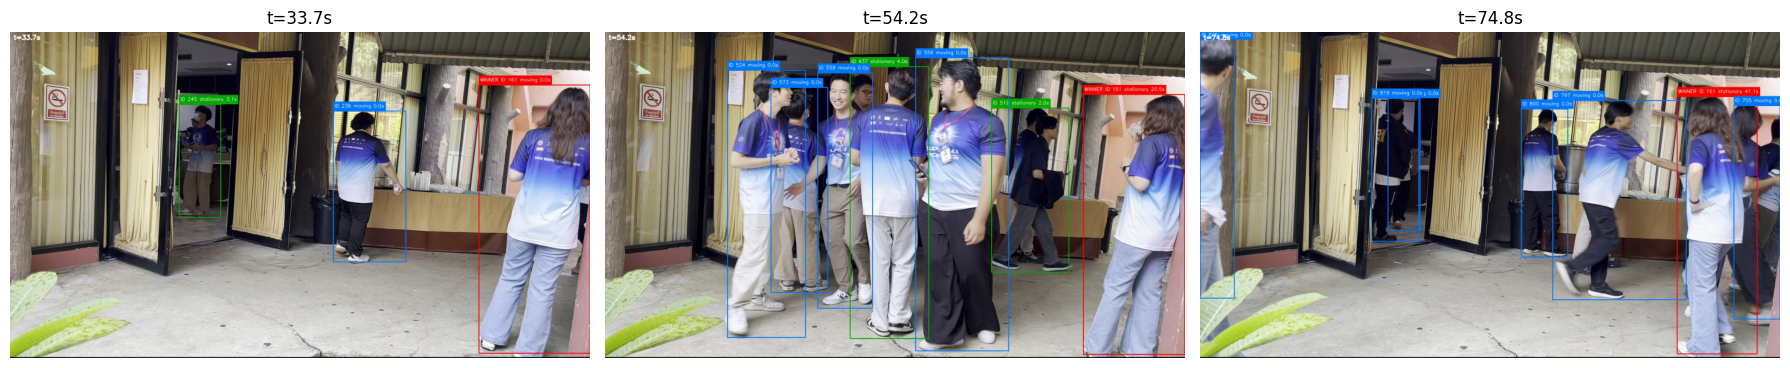

In [18]:
import matplotlib.pyplot as plt

video_path = Path(summary['outputs']['annotated_video'])
fps = summary['metadata']['fps']
times = [
    winner['start_time'],
    (winner['start_time'] + winner['end_time']) / 2,
    winner['end_time'],
]

cap = cv2.VideoCapture(str(video_path))
frames = []
for t in times:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(t * fps))
    ok, frame = cap.read()
    if ok:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Downscale for a lighter notebook output while preserving annotation readability.
        frame = cv2.resize(frame, (960, 540), interpolation=cv2.INTER_AREA)
        frames.append((t, frame))
cap.release()

fig, axes = plt.subplots(1, len(frames), figsize=(18, 5))
if len(frames) == 1:
    axes = [axes]
for ax, (t, frame) in zip(axes, frames):
    ax.imshow(frame)
    ax.set_title(f't={t:.1f}s')
    ax.axis('off')
plt.tight_layout()

# 17. Conclusion

คำตอบจากผล run ปัจจุบัน:

- คนที่อยู่นิ่งนานที่สุดคือ `track_id = 161`
- ระยะเวลา stationary ยาวที่สุดคือ `41.094` วินาที
- ช่วงเวลาคือ `33.699s` ถึง `74.793s`

ข้อควรระวัง:

- ผลลัพธ์เป็น track id ไม่ใช่ตัวตนจริง
- ถ้า tracker เกิด ID switch ผล duration อาจเปลี่ยนได้
- ควรใช้ annotated video และ visual sanity check ตรวจประกอบเสมอ

ถ้าต้องการเพิ่มความน่าเชื่อถือ ควรรันเปรียบเทียบ `yolo11s.pt/imgsz=960` และ `bytetrack.yaml` แล้วดูว่า winner ยังเสถียรหรือไม่


# 18. References

- Ultralytics YOLO tracking docs: https://docs.ultralytics.com/modes/track
- BoT-SORT: https://arxiv.org/abs/2206.14651
- ByteTrack: https://arxiv.org/abs/2110.06864
- HOTA tracking metric: https://arxiv.org/abs/2009.07736
